In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def regime_vol_path(n_steps, sigma_low=0.12, sigma_high=0.35, switch_frac=0.5):
    switch = int(n_steps * switch_frac)
    sigma_path = np.empty(n_steps)
    sigma_path[:switch] = sigma_low
    sigma_path[switch:] = sigma_high
    return sigma_path

def realized_log_variance(S): # benchmark
    logSt_diff = np.diff(np.log(S), axis=1) # diff of logSt
    return np.sum(logSt_diff**2, axis=1)

def simulate_gbm_time_varying_vol(S0=100, mu=0.0, sigma_path=None, T=1.0, n_paths=10000, seed=123):
    rng = np.random.default_rng(seed)
    n_steps = len(sigma_path)
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))

    log_ret = (mu - 0.5 * sigma_path**2) * dt + sigma_path * np.sqrt(dt) * Z #dlogSt
    log_S = np.cumsum(log_ret, axis=1) # integral dlogSt
    S = S0 * np.exp(np.column_stack([np.zeros(n_paths), log_S]))  # add initial time t0 =0 for each path
    return S

n_steps = 252
T = 1.0
sigma_path = regime_vol_path(n_steps) # shape: (n_steps,)

S_regime = simulate_gbm_time_varying_vol(sigma_path=sigma_path, T=T)

rv_integrated = np.sum(sigma_path**2) * (T / n_steps) # integral of variance, 
rv_discrete = realized_log_variance(S_regime) # realized_log_variance: benchmark

sigma_imp = 0.22
var_swap_pnl = rv_discrete - sigma_imp**2 * T



In [43]:
print("Expected integrated realized variance:", rv_integrated)
print("Mean discrete realized variance:", rv_discrete.mean())
print("Mean variance swap P&L:", var_swap_pnl.mean())

Expected integrated realized variance: 0.06844999999999997
Mean discrete realized variance: 0.06833950975860711
Mean variance swap P&L: 0.01993950975860711


In [5]:
def bs_gamma(S, K, tau, sigma):
    tau = np.maximum(tau, 1e-10)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.pdf(d1) / (S * sigma * np.sqrt(tau))

def simulate_gbm_regime(S0=100, T=1.0, n_steps=252, n_paths=1,
                        sigma_low=0.12, sigma_high=0.35,
                        switch_frac=0.5, mu=0.0, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    switch = int(n_steps * switch_frac)

    sigma_path = np.empty(n_steps)
    sigma_path[:switch] = sigma_low
    sigma_path[switch:] = sigma_high

    Z = rng.standard_normal((n_paths, n_steps))
    log_ret = (mu - 0.5 * sigma_path**2) * dt + sigma_path * np.sqrt(dt) * Z
    log_S = np.cumsum(log_ret, axis=1)

    S = S0 * np.exp(np.column_stack([np.zeros(n_paths), log_S]))
    return S, sigma_path

def compare_vanilla_log_pnl(S, sigma_real_path, K=100, sigma_imp=0.22, T=1.0):
    n_paths, n_cols = S.shape
    n_steps = n_cols - 1
    dt = T / n_steps

    S_lag = S[:, :-1]
    S_next = S[:, 1:]

    tau = np.maximum(T - np.arange(n_steps) * dt, 1e-10)

    gamma_call = bs_gamma(S_lag, K, tau, sigma_imp)
    dollar_gamma_call_weight = 0.5 * S_lag**2 * gamma_call # shape: (n_paths, n_steps)

    variance_spread = sigma_real_path**2 - sigma_imp**2 # shape: (n_steps,)

    # Theoretical drift approximation
    pnl_call_theory = dollar_gamma_call_weight * variance_spread * dt

    # Convex negative-log contract: g(S) = -2 log(S / K)
    # Its weight is 0.5 * S^2 * Gamma = 1
    pnl_neglog_theory = variance_spread * dt
    pnl_neglog_theory = np.broadcast_to(pnl_neglog_theory, pnl_call_theory.shape) # expand the short log contract P&L array so that it has the same shape as the vanilla call P&L array

    # Realized discrete variance-swap-like P&L
    log_ret = np.log(S_next / S_lag)
    pnl_neglog_realized = log_ret**2 - sigma_imp**2 * dt

    return {
        "pnl_call_theory": pnl_call_theory,
        "pnl_neglog_theory": pnl_neglog_theory,
        "pnl_neglog_realized": pnl_neglog_realized,
        "dollar_gamma_call_weight": dollar_gamma_call_weight,
        "dollar_gamma_neglog_weight": np.ones_like(dollar_gamma_call_weight),
        "variance_spread": variance_spread,
    }

In [14]:
def bs_gamma(S, K, tau, sigma):
    """
    Black-Scholes Gamma for a European call/put.
    Gamma is the same for calls and puts.
    """
    tau = np.maximum(tau, 1e-10)

    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(tau))

    return gamma


In [97]:
def simulate_gbm_regime_one_path(
    S0=100,
    mu=0.0,
    T=1.0,
    n_steps=252,
    sigma_low=0.12,
    sigma_high=0.35,
    switch_frac=0.5,
    seed=42
):
    rng = np.random.default_rng(seed)
    dt = T / n_steps

    switch_step = int(n_steps * switch_frac)

    sigma_real_path = np.empty(n_steps)
    sigma_real_path[:switch_step] = sigma_low
    sigma_real_path[switch_step:] = sigma_high

    Z = rng.standard_normal(n_steps)

    log_ret = (
        (mu - 0.5 * sigma_real_path**2) * dt
        + sigma_real_path * np.sqrt(dt) * Z
    )

    log_S = np.r_[0.0, np.cumsum(log_ret)]
    S = S0 * np.exp(log_S)

    time_grid = np.arange(n_steps + 1) * dt
    step_time = np.arange(1, n_steps + 1) * dt

    return S, sigma_real_path, time_grid, step_time, dt, switch_step


In [41]:
def compute_pnl_quantities(
    S,
    sigma_real_path,
    K=100,
    sigma_imp=0.22,
    T=1.0
):
    n_steps = len(S) - 1
    dt = T / n_steps

    S_lag = S[:-1]
    S_next = S[1:]

    tau = np.maximum(T - np.arange(n_steps) * dt, 1e-10)

    # Vanilla call gamma
    gamma_call = bs_gamma(S_lag, K, tau, sigma_imp)

    # Dollar gamma weight: 1/2 S^2 Gamma
    dollar_gamma_call_weight = 0.5 * S_lag**2 * gamma_call

    # Variance spread
    variance_spread = sigma_real_path**2 - sigma_imp**2

    pnl_call_theory_step = dollar_gamma_call_weight * variance_spread * dt

    # Short-log contract: g(S) = -  log(S / K)
    # Gamma = 1 / S^2, so 1/2 S^2 Gamma = 1/2
    pnl_neglog_theory_step =  0.5 * variance_spread * dt

    simple_ret = (S_next - S_lag) / S_lag
    log_ret = np.log(S_next / S_lag)

    # Benchmark realized log-variance increment
    rv_log_step = log_ret**2

    # Portfolio replication increment:
    # long negative-log contract + long 2/S stock hedge
    rep_step = 2.0 * (simple_ret - log_ret)

    # Variance-swap-like P&L after paying fixed implied variance
    fixed_var_step = sigma_imp**2 * dt

    pnl_realized_logvar_step = rv_log_step - fixed_var_step
    pnl_realized_rep_step = rep_step - fixed_var_step

    cum_call_theory = np.cumsum(pnl_call_theory_step)
    cum_neglog_theory = np.cumsum(pnl_neglog_theory_step)

    cum_realized_logvar = np.cumsum(pnl_realized_logvar_step)
    cum_realized_rep = np.cumsum(pnl_realized_rep_step)

    return {
        "gamma_call": gamma_call,
        "dollar_gamma_call_weight": dollar_gamma_call_weight,
        "variance_spread": variance_spread,

        "pnl_call_theory_step": pnl_call_theory_step,
        "pnl_neglog_theory_step": pnl_neglog_theory_step,

        "rv_log_step": rv_log_step,
        "rep_step": rep_step,

        "pnl_realized_logvar_step": pnl_realized_logvar_step,
        "pnl_realized_rep_step": pnl_realized_rep_step,

        "cum_call_theory": cum_call_theory,
        "cum_neglog_theory": cum_neglog_theory,

        "cum_realized_logvar": cum_realized_logvar,
        "cum_realized_rep": cum_realized_rep,
    }


In [99]:
S, sigma_real_path, time_grid, step_time, dt, switch_step = simulate_gbm_regime_one_path(
    S0=100,
    mu=0.0,
    T=1.0,
    n_steps=252,
    sigma_low=0.12,
    sigma_high=0.35,
    switch_frac=0.5,
    seed=42
)

In [49]:
results = compute_pnl_quantities(
    S=S,
    sigma_real_path=sigma_real_path,
    K=100,
    sigma_imp=0.22,
    T=1.0
)


In [101]:
switch_time = time_grid[switch_step]

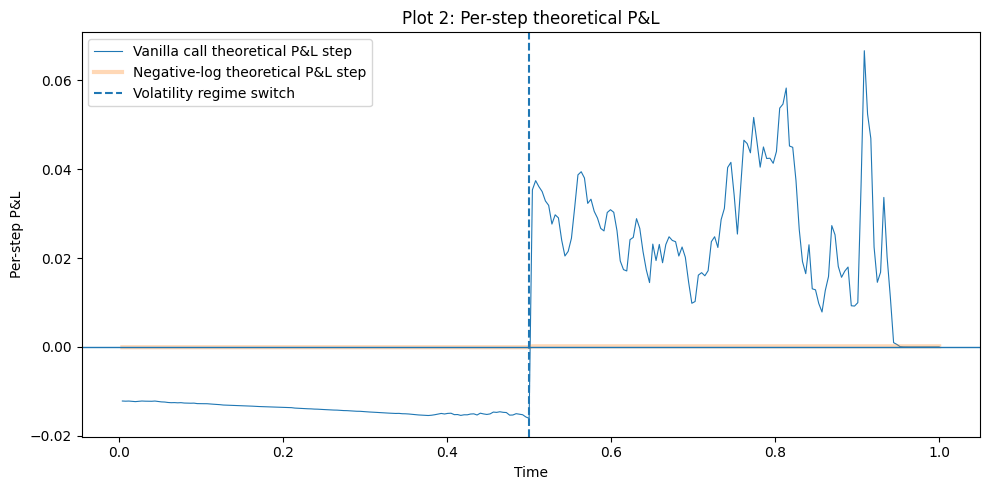

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["pnl_call_theory_step"],
    label="Vanilla call theoretical P&L step",
    linewidth=0.8
)

plt.plot(
    step_time,
    results["pnl_neglog_theory_step"],
    label="Negative-log theoretical P&L step",
    alpha=0.3,
    linewidth=3
)

plt.axhline(0, linewidth=1)
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Plot 2: Per-step theoretical P&L")
plt.xlabel("Time")
plt.ylabel("Per-step P&L")
plt.legend()
plt.tight_layout()
plt.show()

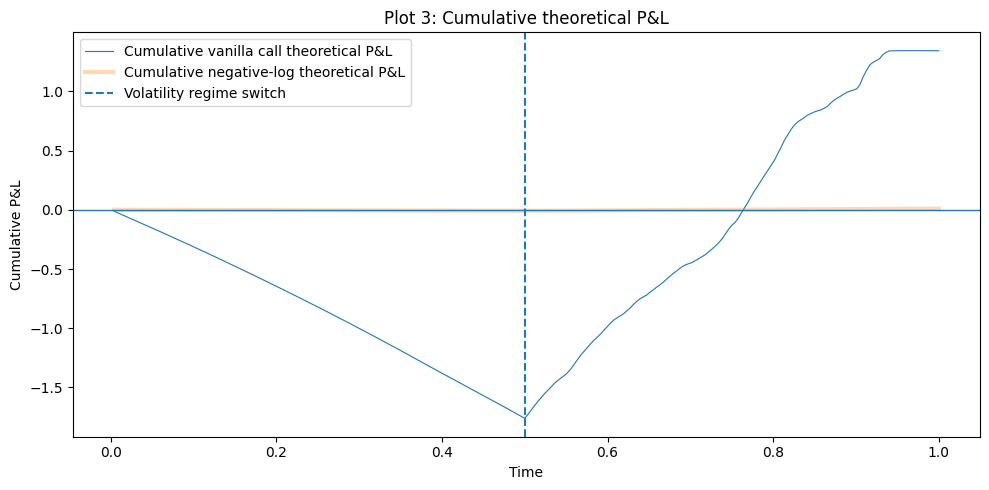

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["cum_call_theory"],
    label="Cumulative vanilla call theoretical P&L",
    linewidth=0.8
)

plt.plot(
    step_time,
    results["cum_neglog_theory"],
    label="Cumulative negative-log theoretical P&L",
    alpha=0.3,
    linewidth=3
)

plt.axhline(0, linewidth=1)
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Plot 3: Cumulative theoretical P&L")
plt.xlabel("Time")
plt.ylabel("Cumulative P&L")
plt.legend()
plt.tight_layout()
plt.show()

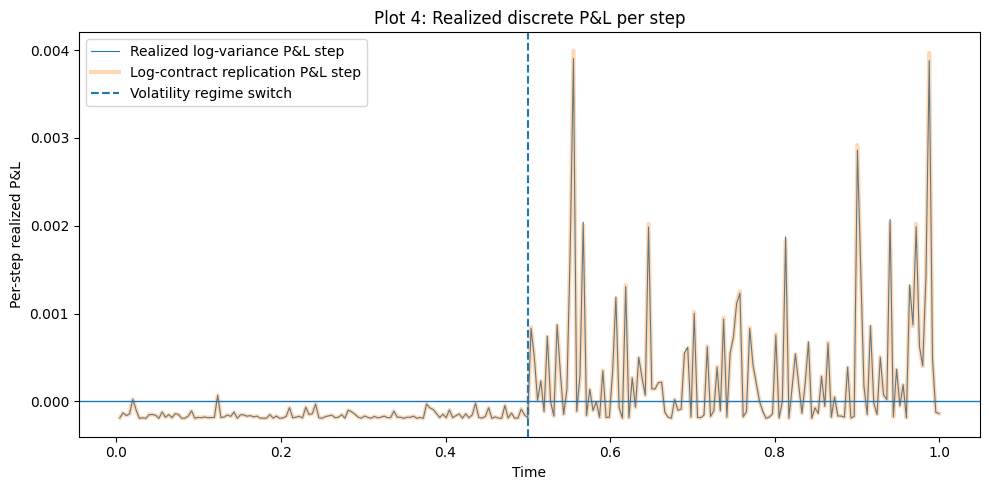

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["pnl_realized_logvar_step"],
    label="Realized log-variance P&L step",
    linewidth=0.8
)

plt.plot(
    step_time,
    results["pnl_realized_rep_step"],
    label="Log-contract replication P&L step",
    alpha=0.3,
    linewidth=3
)

plt.axhline(0, linewidth=1)
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Plot 4: Realized discrete P&L per step")
plt.xlabel("Time")
plt.ylabel("Per-step realized P&L")
plt.legend()
plt.tight_layout()
plt.show()

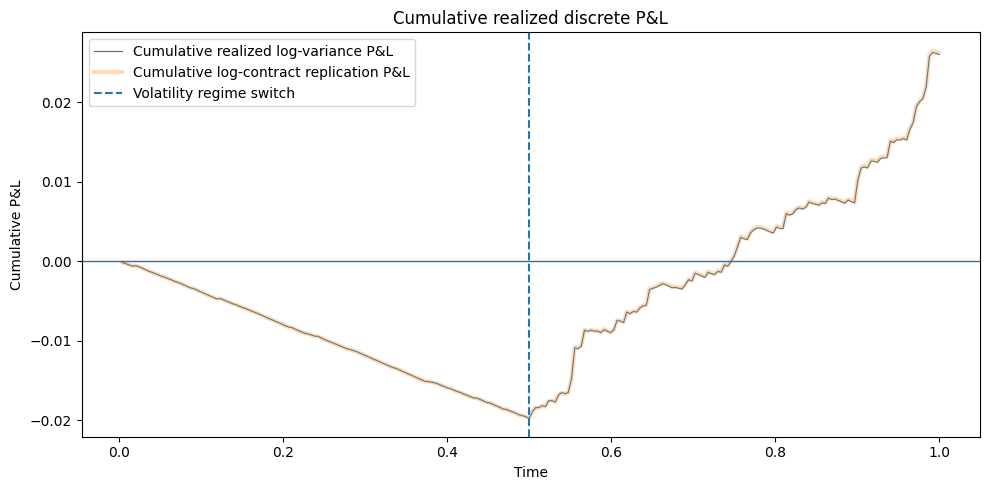

In [53]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["cum_realized_logvar"],
    label="Cumulative realized log-variance P&L",
    linewidth=0.8
)

plt.plot(
    step_time,
    results["cum_realized_rep"],
    label="Cumulative log-contract replication P&L",
    alpha=0.3,
    linewidth=3
)

plt.axhline(0, linewidth=1)
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Cumulative realized discrete P&L")
plt.xlabel("Time")
plt.ylabel("Cumulative P&L")
plt.legend()
plt.tight_layout()
plt.show()

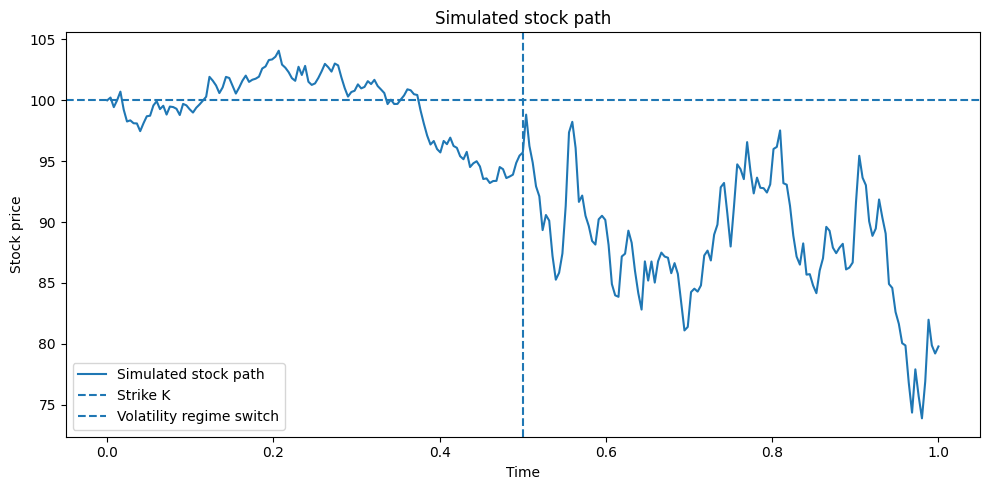

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(time_grid, S, label="Simulated stock path")
plt.axhline(100, linestyle="--", label="Strike K")
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Simulated stock path")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.legend()
plt.tight_layout()
plt.show()

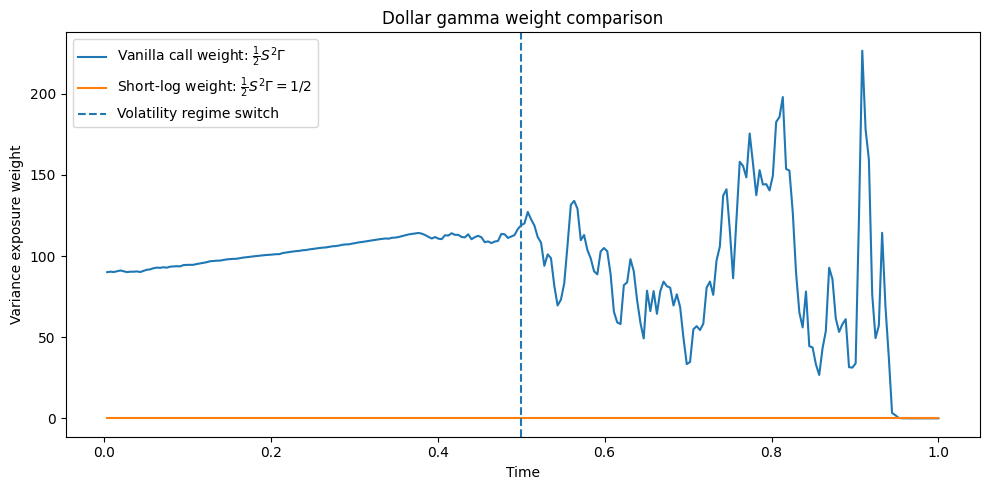

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["dollar_gamma_call_weight"],
    label=r"Vanilla call weight: $\frac{1}{2}S^2\Gamma$"
)

plt.plot(
    step_time,
    np.ones_like(step_time)*0.5,
    label=r"Short-log weight: $\frac{1}{2}S^2\Gamma = 1/2$"
)

plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Dollar gamma weight comparison")
plt.xlabel("Time")
plt.ylabel("Variance exposure weight")
plt.legend()
plt.tight_layout()
plt.show()

In [103]:
def compute_pnl_quantities(
    S,
    sigma_real_path,
    K=100,
    sigma_imp=0.22,
    T=1.0,
    log_scale=1.0,
):
    """
    Compare a vanilla call with a short log contract.

    log_scale= 1 corresponds to:
        g(S) = - log(S / K)

    Its variance-exposure weight is:
        0.5 * S^2 * Gamma = 1/2
    """
    n_steps = len(S) - 1
    dt = T / n_steps

    S_lag = S[:-1]
    S_next = S[1:]

    tau = np.maximum(
        T - np.arange(n_steps) * dt,
        1e-10,
    )

    # --------------------------------------------------------
    # 1. Raw vanilla-call variance exposure
    # --------------------------------------------------------
    gamma_call = bs_gamma(
        S=S_lag,
        K=K,
        tau=tau,
        sigma=sigma_imp,
    )

    raw_call_weight = 0.5 * S_lag**2 * gamma_call

    # --------------------------------------------------------
    # 2. short log variance exposure
    #
    # For g(S) = -a log(S/K):
    # Gamma = a / S^2
    # 0.5 * S^2 * Gamma = a / 2
    # --------------------------------------------------------
    target_log_weight = 0.5 * log_scale

    # Match the call's initial exposure to the log-contract exposure.
    # This is calculated once and remains fixed.
    call_notional = target_log_weight / raw_call_weight[0]

    normalized_call_weight = (
        call_notional * raw_call_weight
    )

    shortlog_weight = np.full(
        n_steps,
        target_log_weight,
    )

    # --------------------------------------------------------
    # 3. Theoretical variance-spread P&L
    # --------------------------------------------------------
    variance_spread = (
        sigma_real_path**2 - sigma_imp**2
    )

    pnl_call_raw_step = (
        raw_call_weight
        * variance_spread
        * dt
    )

    pnl_call_normalized_step = (
        normalized_call_weight
        * variance_spread
        * dt
    )

    pnl_shortlog_theory_step = (
        shortlog_weight
        * variance_spread
        * dt
    )

    # --------------------------------------------------------
    # 4. Discrete realized-variance quantities
    # --------------------------------------------------------
    return_St = (
        S_next - S_lag
    ) / S_lag

    return_logSt = np.log(
        S_next / S_lag
    )

    rv_log_step = return_logSt**2

    # Delta-hedged negative-log portfolio:
    # g(S) = -a log(S/K)
    # hedge shares = a / S
    rep_step = log_scale * (
        return_St - return_logSt
    )

    # For log_scale=1, target_log_weight=1/2,
    # so this is the standard full variance fixed leg.
    fixed_leg_step = (
        target_log_weight
        * sigma_imp**2
        * dt
    )

    pnl_realized_benchmark_step = (
        target_log_weight * rv_log_step
        - fixed_leg_step
    )

    pnl_realized_rep_step = (
        rep_step - fixed_leg_step
    )

    return {
        # Gamma and notionals
        "gamma_call": gamma_call,
        "call_notional": call_notional,
        "target_log_weight": target_log_weight,

        # Weights
        "raw_call_weight": raw_call_weight,
        "normalized_call_weight": normalized_call_weight,
        "shortlog_weight": shortlog_weight,

        # Theoretical P&L
        "pnl_call_raw_step": pnl_call_raw_step,
        "pnl_call_normalized_step": pnl_call_normalized_step,
        "pnl_shortlog_theory_step": pnl_shortlog_theory_step,

        # Realized discrete P&L
        "rv_log_step": rv_log_step,
        "rep_step": rep_step,
        "pnl_realized_benchmark_step": pnl_realized_benchmark_step,
        "pnl_realized_rep_step": pnl_realized_rep_step,

        # Cumulative theoretical P&L
        "cum_call_raw": np.cumsum(pnl_call_raw_step),
        "cum_call_normalized": np.cumsum(
            pnl_call_normalized_step
        ),
        "cum_shortlog_theory": np.cumsum(
            pnl_shortlog_theory_step
        ),

        # Cumulative realized P&L
        "cum_realized_benchmark": np.cumsum(
            pnl_realized_benchmark_step
        ),
        "cum_realized_rep": np.cumsum(
            pnl_realized_rep_step
        ),
    }

In [105]:
results = compute_pnl_quantities(
    S=S,
    sigma_real_path=sigma_real_path,
    K=100,
    sigma_imp=0.22,
    T=1.0,
    log_scale=1.0,
)

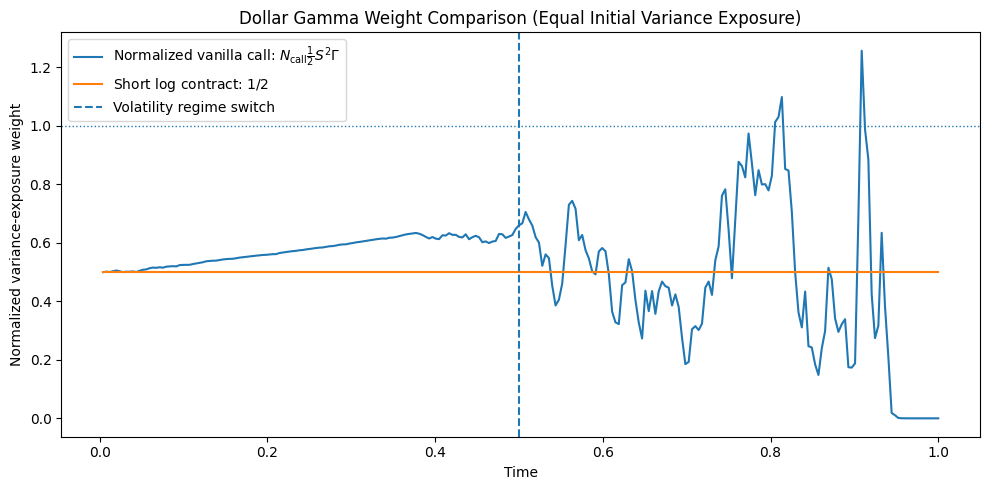

In [107]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["normalized_call_weight"],
    label=(
        r"Normalized vanilla call: "
        r"$N_{\mathrm{call}}\frac{1}{2}S^2\Gamma$"
    ),
)

plt.plot(
    step_time,
    results["shortlog_weight"],
    label=r"Short log contract: $1/2$",
)

plt.axhline(
    1.0,
    linewidth=1,
    linestyle=":",
)

plt.axvline(
    switch_time,
    linestyle="--",
    label="Volatility regime switch",
)

plt.title("Dollar Gamma Weight Comparison (Equal Initial Variance Exposure)")
plt.xlabel("Time")
plt.ylabel("Normalized variance-exposure weight")
plt.legend()
plt.tight_layout()
plt.show()

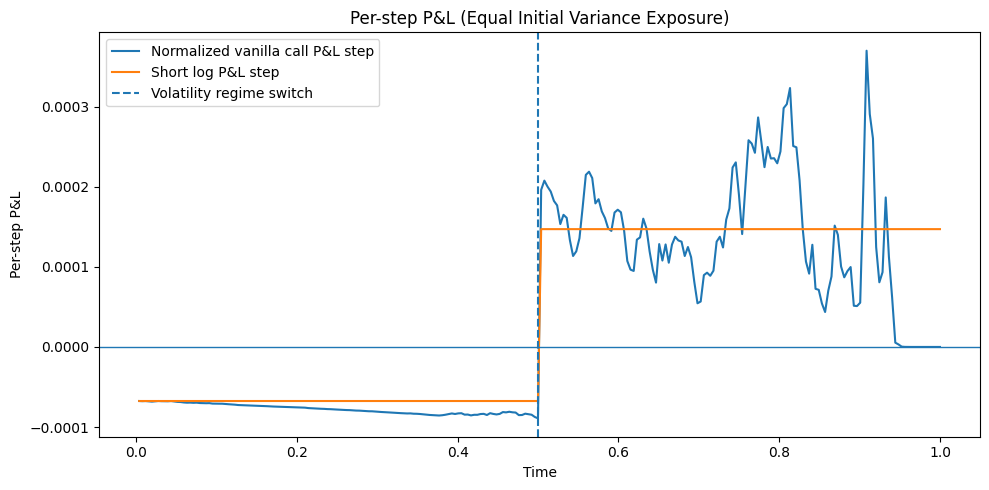

In [109]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["pnl_call_normalized_step"],
    label="Normalized vanilla call P&L step",
)

plt.plot(
    step_time,
    results["pnl_shortlog_theory_step"],
    label="Short log P&L step",
)

plt.axhline(0, linewidth=1)

plt.axvline(
    switch_time,
    linestyle="--",
    label="Volatility regime switch",
)

plt.title(
    "Per-step P&L (Equal Initial Variance Exposure)"
)
plt.xlabel("Time")
plt.ylabel("Per-step P&L")
plt.legend()
plt.tight_layout()
plt.show()

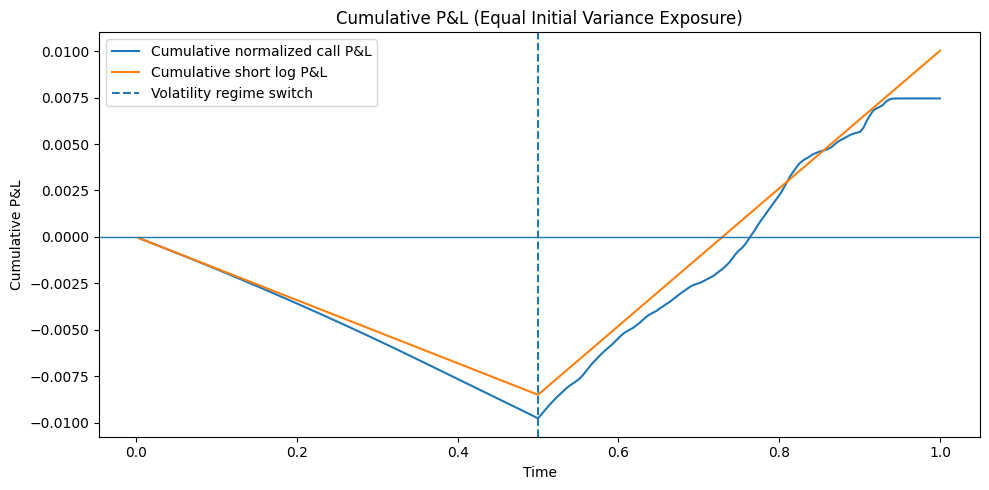

In [111]:
plt.figure(figsize=(10, 5))

plt.plot(
    step_time,
    results["cum_call_normalized"],
    label="Cumulative normalized call P&L",
)

plt.plot(
    step_time,
    results["cum_shortlog_theory"],
    label="Cumulative short log P&L",
)

plt.axhline(0, linewidth=1)

plt.axvline(
    switch_time,
    linestyle="--",
    label="Volatility regime switch",
)

plt.title(
    "Cumulative P&L (Equal Initial Variance Exposure)"
)
plt.xlabel("Time")
plt.ylabel("Cumulative P&L")
plt.legend()
plt.tight_layout()
plt.show()

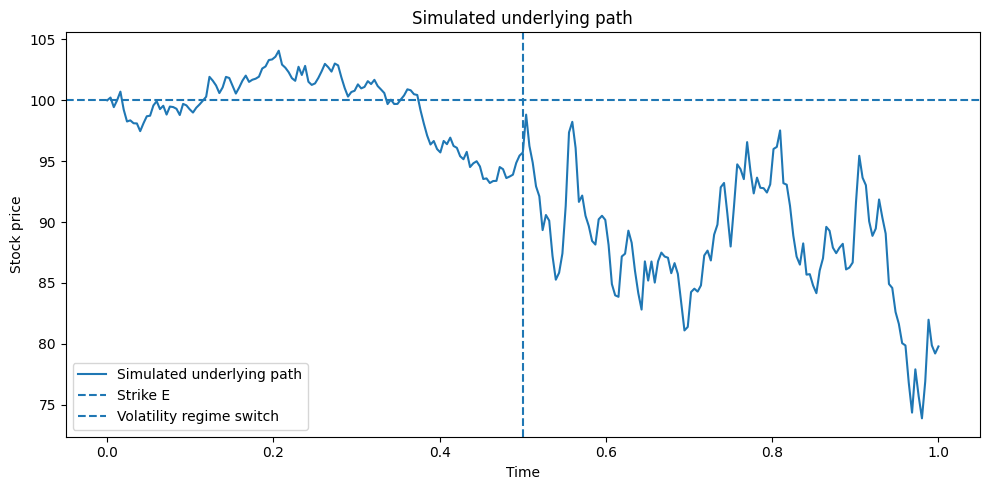

In [115]:
plt.figure(figsize=(10, 5))

plt.plot(time_grid, S, label="Simulated underlying path")
plt.axhline(100, linestyle="--", label="Strike E")
plt.axvline(switch_time, linestyle="--", label="Volatility regime switch")

plt.title("Simulated underlying path")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.legend()
plt.tight_layout()
plt.show()